In [3]:
import pandas as pd

print("Step 1")

file = open("../data/Churn_Modelling.csv", "r")

print("Step 2")

Step 1
Step 2


In [4]:
import pandas as pd

df = pd.read_csv("../data/Churn_Modelling.csv", nrows=5)

print("Step 2")

print(df.head())

Step 2
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4     

In [5]:
import pandas as pd

df = pd.read_csv("../data/Churn_Modelling.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [6]:
print(df["Exited"].value_counts())

print("\nPercentage:")

print(df["Exited"].value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [7]:
# Remove unnecessary columns

df = df.drop(columns=[
    "RowNumber",
    "CustomerId",
    "Surname"
])

print(df.shape)

(10000, 11)


In [8]:
# Geography encoding
df["Germany"] = (df["Geography"] == "Germany").astype(int)
df["Spain"] = (df["Geography"] == "Spain").astype(int)

# Gender encoding
df["Gender"] = (df["Gender"] == "Male").astype(int)

# Remove original Geography column
df = df.drop(columns=["Geography"])

# Check first few rows
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [9]:
# Features and target

X = df.drop("Exited", axis=1)
y = df["Exited"]

print(X.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Germany', 'Spain']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8000, 11)
Testing Shape: (2000, 11)


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8665


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1551   56]
 [ 211  182]]


In [14]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8571952225552646


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)

lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression ROC-AUC:", lr_auc)

Logistic Regression Accuracy: 0.811
Logistic Regression ROC-AUC: 0.7788998829864888


In [16]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, accuracy],
    "ROC_AUC": [lr_auc, auc]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.8110,0.778900
1,Random Forest,0.8665,0.857195


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [14]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,Age,0.239783
8,EstimatedSalary,0.146638
0,CreditScore,0.144214
4,Balance,0.138613
5,NumOfProducts,0.130255
3,Tenure,0.082427
7,IsActiveMember,0.041110
9,Germany,0.025711
1,Gender,0.019258
6,HasCrCard,0.018722


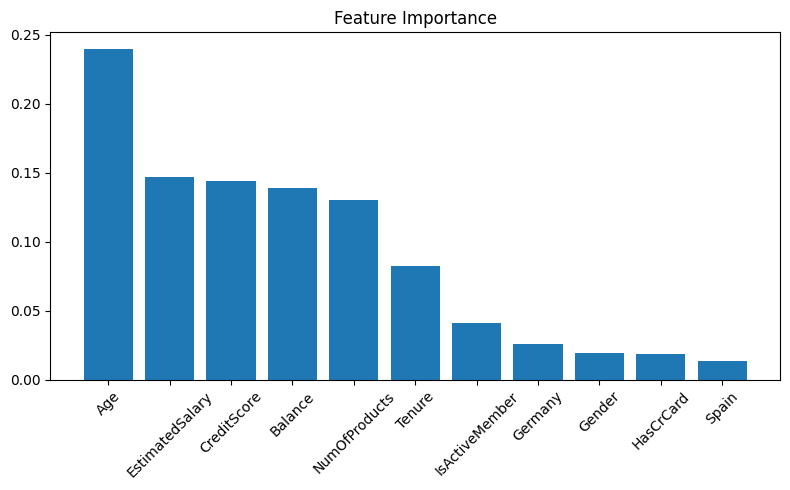

In [15]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.reset_index(drop=True)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()

plt.show()

In [16]:
import pickle

# Save model
with open("../models/churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature order
with open("../models/feature_order.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model, scaler and feature order saved successfully!")

Model, scaler and feature order saved successfully!
